# Evolving a Lunar Lander with differentiable Genetic Programming

## Installation
To install the required libraries run the command:

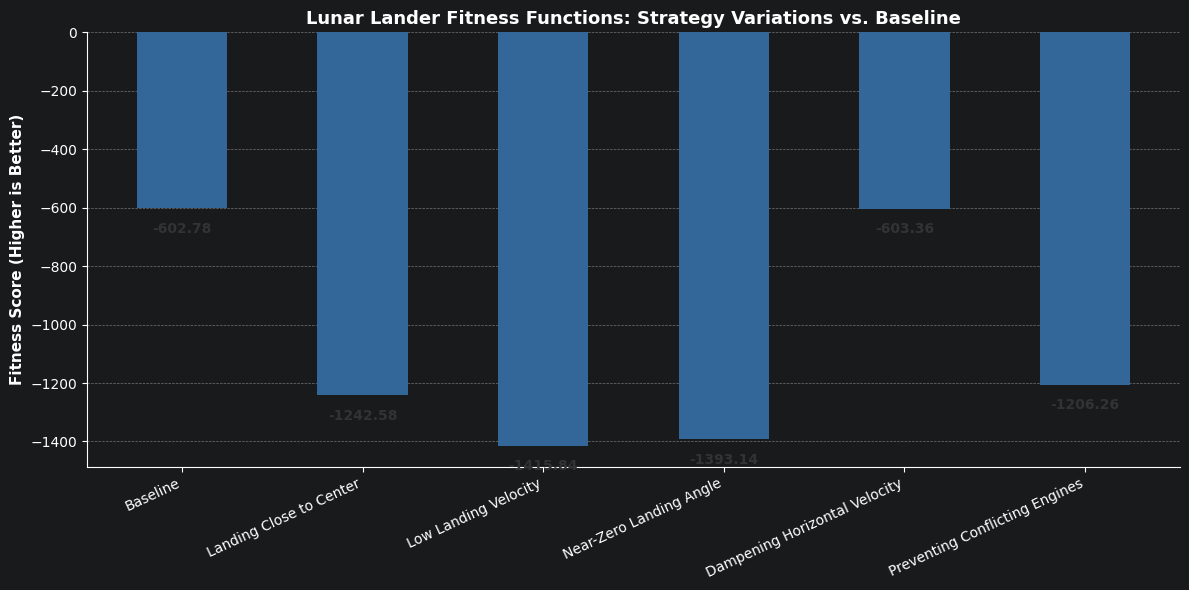

In [261]:
import matplotlib.pyplot as plt
import numpy as np

# Updated short names tailored for your presentation slide
labels = [
    'Baseline',
    'Landing Close to Center',
    'Low Landing Velocity',
    'Near-Zero Landing Angle',
    'Dampening Horizontal Velocity',
    'Preventing Conflicting Engines'
]
scores = [-602.78, -1242.58, -1415.84, -1393.14, -603.36, -1206.26]

# Set up the figure size to fit long horizontal labels cleanly
plt.figure(figsize=(12, 6))

# Plot bars using a clean blue hue
bars = plt.bar(labels, scores, color='#336699', edgecolor='none', width=0.5)


# Customize axes and grid
plt.ylabel('Fitness Score (Higher is Better)', fontsize=11, fontweight='bold')
plt.title('Lunar Lander Fitness Functions: Strategy Variations vs. Baseline', fontsize=13, fontweight='bold')
plt.xticks(rotation=25, ha='right')  # Rotated for slide legibility

# Add horizontal gridlines behind the bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', color='#cccccc')

# Remove the top and right spines for a clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add text values underneath each bar for precision
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 45, f'{yval:.2f}',
             ha='center', va='top', fontweight='bold', color='#333333')

# Tighten layout and render
plt.tight_layout()
plt.show()

In [262]:
# !pip install -r requirements-pinned.txt

## Imports
Imports from the standard genepro-multi library are done here. Any adjustments (e.g. different operators) should be made in the notebook. For example:

```
class SmoothOperator(Node):
  def __init__(self):
    super(SmoothOperator,self).__init__()
    self.arity = 1
    self.symb = "SmoothOperator"

  def _get_args_repr(self, args):
    return self._get_typical_repr(args,'before')

  def get_output(self, X):
    c_outs = self._get_child_outputs(X)
    return np.smoothOperation(c_outs[0])

  def get_output_pt(self, X):
    c_outs = self._get_child_outputs_pt(X)
    return torch.smoothOperation(c_outs[0])
```

In [263]:
import gymnasium as gym

from genepro.node_impl import *
from genepro.evo import Evolution
from genepro.node_impl import Constant

import torch
import torch.optim as optim

import random
import os
import copy
from collections import namedtuple, deque

import matplotlib.pyplot as plt
from matplotlib import animation

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

## Reinforcement Learning Setup
Here we first setup the Gymnasium environment. Please see https://gymnasium.farama.org/environments/box2d/lunar_lander/ for more information on the environment. 

Then a memory buffer is made. This is a buffer in which state transitions are stored. When the buffer reaches its maximum capacity old transitions are replaced by new ones.

A frame buffer is initialised used to later store animation frames of the environment.

In [264]:
env = gym.make("LunarLander-v2", render_mode="rgb_array")

In [265]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

    def __iadd__(self, other):
      self.memory += other.memory
      return self 

    def __add__(self, other):
      self.memory = self.memory + other.memory 
      return self

In [266]:
frames = []

## Fitness Function

Here you get to be creative. The default setup evaluates 5 episodes of 300 frames. Think of what action to pick and what fitness function to use. The Multi-tree takes an input of $n \times d$ where $n$ is a batch of size 1.

In [267]:
def original_fitness_function_pt(multitree, num_episodes=5, episode_duration=300, render=False, ignore_done=False):
  memory = ReplayMemory(10000)
  rewards = []

  for ep in range(num_episodes):
    # get initial state of the environment
    observation = env.reset(seed=SEED + ep)
    observation = observation[0]

    for _ in range(episode_duration):
      if render:
        frames.append(env.render())

      input_sample = torch.from_numpy(observation.reshape((1,-1))).float()

      action = torch.argmax(multitree.get_output_pt(input_sample))
      observation, reward, terminated, truncated, info = env.step(action.item())
      rewards.append(reward)
      output_sample = torch.from_numpy(observation.reshape((1,-1))).float()
      memory.push(input_sample, torch.tensor([[action.item()]]), output_sample, torch.tensor([reward]))
      if (terminated or truncated) and not ignore_done:
        break

  fitness = np.sum(rewards)

  return fitness, memory

In [268]:
def fitness_function_pt(multitree, num_episodes=10, episode_duration=500, render=False, ignore_done=False):
  memory = ReplayMemory(10000)
  rewards = []

  for ep in range(num_episodes):
    # get initial state of the environment
    observation = env.reset(seed=SEED + ep)
    observation = observation[0]
    
    for _ in range(episode_duration):
      if render:
        frames.append(env.render())

      input_sample = torch.from_numpy(observation.reshape((1,-1))).float()

      action = torch.argmax(multitree.get_output_pt(input_sample))
      observation, reward, terminated, truncated, info = env.step(action.item())


      # vx=abs(observation[2])
      # vy=abs(observation[3])
      # left_contact=observation[6]
      # right_contact=observation[7]
      # horizontal_flag_distance= abs(observation[0])
      # terrain_height= observation[1]#reward the lander for landing softly
      # if (terminated or truncated):
      #   if (left_contact == 1 or right_contact == 1) and terrain_height < 0.1:
      #     # Sets 95% of the reward within 5% of total screen width (from x = -0.05 to +0.05)
      #     width = 0.016
      #
      #     # Compute non-linear Gaussian decay
      #     distance_bonus = 100.0 * np.exp(-(horizontal_flag_distance**2) / (2 * width**2))
      #     reward += distance_bonus
      #
      #     # This will only print if the rocket lands exceptionally close to dead center
      #     if distance_bonus > 95:
      #       print(f"Bullseye landing! Distance bonus applied: +{distance_bonus:.2f}")




      rewards.append(reward)
      output_sample = torch.from_numpy(observation.reshape((1,-1))).float()
      memory.push(input_sample, torch.tensor([[action.item()]]), output_sample, torch.tensor([reward]))

      vx = abs(observation[2])
      vy = abs(observation[3])
      left_contact = observation[6]
      right_contact = observation[7]
      horizontal_flag_distance = abs(observation[0])
      terrain_height = observation[1]

      if (terminated or truncated) and not ignore_done:
        # Penalty for high velocity during a touchdown attempt
        if left_contact == 1 or right_contact == 1:
          velocity_penalty = -200.0 * (vx + vy)
          reward += velocity_penalty
          rewards.append(velocity_penalty)
        break

  fitness = np.sum(rewards)
  
  return fitness, memory

In [269]:
def fitness_function_pt2(multitree,
                     num_episodes=10,
                     episode_duration=500,
                     # tree_penalty=0.05
                     tree_penalty=0.1
):

    memory = ReplayMemory(10000)
    episode_returns = []

    for ep in range(num_episodes):
        observation = env.reset(seed=SEED + ep)
        observation = observation[0]

        episode_reward = 0

        for _ in range(episode_duration):
            input_sample = torch.from_numpy(
                observation.reshape((1, -1))
            ).float()

            action = torch.argmax(
                multitree.get_output_pt(input_sample)
            )

            observation, reward, terminated, truncated, _ = \
                env.step(action.item())

            episode_reward += reward

            output_sample = torch.from_numpy(
                observation.reshape((1, -1))
            ).float()

            memory.push(
                input_sample,
                torch.tensor([[action.item()]]),
                output_sample,
                torch.tensor([reward])
            )

            if terminated or truncated:
                break

        episode_returns.append(episode_reward)

    mean_return = np.mean(episode_returns)

    # Count nodes across all trees
    # tree_size = multitree.get_size()
    tree_size = sum(len(child) for child in multitree.children)

    fitness = mean_return - tree_penalty * tree_size

    return fitness, memory

In [270]:
CURRENT_EPISODE_DURATION = 150

def fitness_function_pt3(
    multitree,
    num_episodes=10,
    episode_duration=None,
    tree_penalty=0.1
):
    global CURRENT_EPISODE_DURATION

    if episode_duration is None:
        episode_duration = CURRENT_EPISODE_DURATION

    memory = ReplayMemory(10000)
    episode_returns = []

    for ep in range(num_episodes):
        observation = env.reset(seed=SEED + ep)
        observation = observation[0]

        episode_reward = 0

        for _ in range(episode_duration):
            input_sample = torch.from_numpy(
                observation.reshape((1, -1))
            ).float()

            action = torch.argmax(
                multitree.get_output_pt(input_sample)
            )

            observation, reward, terminated, truncated, _ = \
                env.step(action.item())

            x = abs(observation[0])
            y = observation[1]
            vx = abs(observation[2])
            vy = abs(observation[3])
            angle = abs(observation[4])

            reward -= 0.5 * x
            reward -= 0.2 * vx
            reward -= 0.3 * vy
            reward -= 0.2 * angle

            episode_reward += reward

            output_sample = torch.from_numpy(
                observation.reshape((1, -1))
            ).float()

            memory.push(
                input_sample,
                torch.tensor([[action.item()]]),
                output_sample,
                torch.tensor([reward])
            )

            if terminated or truncated:
                break

        episode_returns.append(episode_reward)

    mean_return = np.mean(episode_returns)
    std_return = np.std(episode_returns)

    # Count nodes across all trees
    # tree_size = multitree.get_size()
    tree_size = sum(len(child) for child in multitree.children)

    # fitness = mean_return - tree_penalty * tree_size

    fitness = (
        mean_return
        - 0.25 * std_return
        - tree_penalty * tree_size
    )

    return fitness, memory

In [271]:
def fitness_function_pt4(
    multitree,
    num_episodes=20,
    episode_duration=300,
    render=False,
    ignore_done=False,
):
    memory = ReplayMemory(10000)
    episode_returns = []

    for ep in range(num_episodes):
        observation = env.reset(seed=SEED + ep)
        observation = observation[0]

        total_reward = 0

        for _ in range(episode_duration):
            if render:
                frames.append(env.render())

            input_sample = torch.from_numpy(
                observation.reshape((1, -1))
            ).float()

            action = torch.argmax(
                multitree.get_output_pt(input_sample)
            )

            observation, reward, terminated, truncated, info = env.step(
                action.item()
            )

            output_sample = torch.from_numpy(
                observation.reshape((1, -1))
            ).float()

            memory.push(
                input_sample,
                torch.tensor([[action.item()]]),
                output_sample,
                torch.tensor([reward]),
            )

            total_reward += reward

            if (terminated or truncated) and not ignore_done:

                x_pos = observation[0]
                y_pos = observation[1]
                vx = observation[2]
                vy = observation[3]
                angle = observation[4]
                left_contact = observation[6]
                right_contact = observation[7]

                # landing quality bonus
                if left_contact or right_contact:

                    distance_bonus = (
                        200.0
                        * np.exp(
                            -(x_pos**2) / 0.02
                            - ((y_pos - 0.1) ** 2) / 0.02
                        )
                    )

                    velocity_penalty = (
                        50.0 * (abs(vx) + abs(vy))
                    )

                    angle_penalty = (
                        25.0 * abs(angle)
                    )

                    total_reward += (
                        distance_bonus
                        - velocity_penalty
                        - angle_penalty
                    )

                break

        episode_returns.append(total_reward)

    fitness = np.median(episode_returns)

    return fitness, memory

## Evolution Setup
Here the leaf and internal nodes are defined. Think about the odds of sampling a constant in this default configurations. Also think about any operators that could be useful and add them here. 

Adjust the population size (multiple of 8 if you want to use the standard tournament selection), max generations and max tree size to taste. Be aware that each of these settings can increase the runtime.

In [272]:
num_features = env.observation_space.shape[0]
leaf_nodes = [Feature(i) for i in range(num_features)]
leaf_nodes = leaf_nodes + [Constant()] # Think about the probability of sampling a coefficient
# internal_nodes = [Plus(),Minus(),Times(),Div()] #Add your own operators here
internal_nodes = [Plus(), Minus(), Times(), Sqrt(), Log(), Max(), Tanh(), Abs(), Div()] #Add your own operators here

# evo = Evolution(
#   # original_fitness_function_pt,
#   # fitness_function_pt,
#   # fitness_function_pt2,
#   fitness_function_pt3,
#   # fitness_function_pt4,
#   internal_nodes,
#   leaf_nodes,
#   4,
#   # pop_size=8,
#   # pop_size=16,
#   # pop_size=32,
#   # pop_size=64,
#   pop_size=128,
#   # max_gens=10,
#   # max_gens=35,
#   max_gens=50,
#   # max_gens=100,
#   # max_tree_size=31,
#   # max_tree_size=32,
#   # max_tree_size=48,
#   max_tree_size=63,
#   n_jobs=8,
#   verbose=True,
#   init_method="ramped_half_and_half",
#   elite_archive_size=0,
#   seed=SEED)

evo = Evolution(
    fitness_function_pt3,
    internal_nodes,
    leaf_nodes,
    4,
    pop_size=128,
    max_gens=20,
    max_tree_size=63,
    n_jobs=8,
    verbose=True,
    init_method="ramped_half_and_half",
    elite_archive_size=0,
    seed=SEED
)

## Evolve
Running this cell will use all the settings above as parameters

In [273]:
# RUN_CURRICULUM = False
RUN_CURRICULUM = True

if RUN_CURRICULUM:
    import copy
    import time

    CURRENT_EPISODE_DURATION = 150

    evo = Evolution(
        fitness_function_pt3,
        internal_nodes,
        leaf_nodes,
        4,
        pop_size=128,
        max_gens=50,
        max_tree_size=63,
        n_jobs=8,
        verbose=True,
        init_method="ramped_half_and_half",
        elite_archive_size=0,
        seed=SEED
    )

    curriculum = [
        (150, 15),
        (300, 15),
        (500, 20),
    ]

    best_fitness = -np.inf

    evo.start_time = time.time()
    evo._initialize_population()

    for duration, generations in curriculum:
        print(f"\n=== Curriculum stage: {duration} steps for {generations} generations ===")

        CURRENT_EPISODE_DURATION = duration

        for _ in range(generations):
            evo._perform_generation()

            current_best = evo.best_of_gens[-1]

            if current_best.fitness > best_fitness:
                best_fitness = current_best.fitness
                best_tree = copy.deepcopy(current_best)

            print(
                f"gen: {evo.num_gens}, "
                f"duration: {duration}, "
                f"best fitness: {current_best.fitness:.3f}, "
                f"size: {len(current_best)}"
            )
else:
    evo.evolve()

/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_check


=== Curriculum stage: 150 steps for 15 generations ===
gen: 1, duration: 150, best fitness: -158.982, size: 11
gen: 2, duration: 150, best fitness: -153.174, size: 10
gen: 3, duration: 150, best fitness: -148.467, size: 25
gen: 4, duration: 150, best fitness: -148.467, size: 25
gen: 5, duration: 150, best fitness: -89.436, size: 25
gen: 6, duration: 150, best fitness: -89.436, size: 25
gen: 7, duration: 150, best fitness: -80.153, size: 25
gen: 8, duration: 150, best fitness: -79.758, size: 39
gen: 9, duration: 150, best fitness: -46.215, size: 25
gen: 10, duration: 150, best fitness: -38.191, size: 25
gen: 11, duration: 150, best fitness: -37.491, size: 25
gen: 12, duration: 150, best fitness: -35.000, size: 25
gen: 13, duration: 150, best fitness: -34.408, size: 28
gen: 14, duration: 150, best fitness: -25.344, size: 39
gen: 15, duration: 150, best fitness: 68.977, size: 31

=== Curriculum stage: 300 steps for 15 generations ===
gen: 16, duration: 300, best fitness: -1.626, size: 31

# Test

In [278]:
VALIDATION_SEEDS = [10_000 + i for i in range(20)]
INVALID_FITNESS = -1e9

def _make_diagnostics(episode_returns=None, episode_lengths=None, successes=0, crashes=0, timeouts=0, invalid_outputs=0, action_counts=None, main_engine_brake_steps=0, low_altitude_fast_descent_steps=0, final_abs_vys=None, tree_size=0, parsimony_penalty=0.0, heuristic_match_steps=0, no_main_engine_episodes=0, stats=None):
  if stats is not None:
    episode_returns = stats["episode_returns"]
    episode_lengths = stats["episode_lengths"]
    successes = stats["successes"]
    crashes = stats["crashes"]
    timeouts = stats["timeouts"]
    invalid_outputs = stats["invalid_outputs"]
    action_counts = stats["action_counts"]
    main_engine_brake_steps = stats["main_engine_brake_steps"]
    low_altitude_fast_descent_steps = stats["low_altitude_fast_descent_steps"]
    final_abs_vys = stats["final_abs_vys"]
    tree_size = stats["tree_size"]
    parsimony_penalty = stats["parsimony_penalty"]
    heuristic_match_steps = stats["heuristic_match_steps"]
    no_main_engine_episodes = stats["no_main_engine_episodes"]

  episode_returns = episode_returns or []
  episode_lengths = episode_lengths or []
  action_counts = action_counts or {action: 0 for action in range(4)}
  final_abs_vys = final_abs_vys or []
  returns = np.array(episode_returns, dtype=float)

  return {
    "mean_return": float(np.mean(returns)) if len(returns) else INVALID_FITNESS,
    "std_return": float(np.std(returns)) if len(returns) else 0.0,
    "min_return": float(np.min(returns)) if len(returns) else INVALID_FITNESS,
    "max_return": float(np.max(returns)) if len(returns) else INVALID_FITNESS,
    "episode_returns": episode_returns,
    "episode_lengths": episode_lengths,
    "successes": successes,
    "crashes": crashes,
    "timeouts": timeouts,
    "invalid_outputs": invalid_outputs,
    "action_counts": action_counts,
    "main_engine_brake_steps": main_engine_brake_steps,
    "low_altitude_fast_descent_steps": low_altitude_fast_descent_steps,
    "mean_final_abs_vy": float(np.mean(final_abs_vys)) if len(final_abs_vys) else 0.0,
    "tree_size": tree_size,
    "parsimony_penalty": float(parsimony_penalty),
    "heuristic_match_steps": heuristic_match_steps,
    "no_main_engine_episodes": no_main_engine_episodes,
  }

def get_test_score(tree, seeds=VALIDATION_SEEDS, episode_duration=1000):
    episode_returns = []
    episode_lengths = []
    successes = 0
    crashes = 0
    timeouts = 0
    invalid_outputs = 0

    for seed in seeds:
      observation = env.reset(seed=seed)[0]
      episode_return = 0.0
      final_reward = 0.0
      terminated = False
      truncated = False
      step_count = 0

      for step_count in range(1, episode_duration + 1):
        input_sample = torch.from_numpy(observation.reshape((1,-1))).float()
        output = tree.get_output_pt(input_sample)
        if not torch.isfinite(output).all():
          invalid_outputs += 1
          episode_return = INVALID_FITNESS
          break

        action = torch.argmax(output)
        observation, reward, terminated, truncated, info = env.step(action.item())
        final_reward = reward
        episode_return += reward
        if (terminated or truncated):
            break

      episode_returns.append(episode_return)
      episode_lengths.append(step_count)
      landed = terminated and final_reward >= 100 and observation[6] == 1.0 and observation[7] == 1.0
      successes += int(landed)
      crashes += int(terminated and not landed)
      timeouts += int(truncated or (not terminated and step_count >= episode_duration))

    return _make_diagnostics(
      episode_returns, episode_lengths, successes, crashes, timeouts, invalid_outputs=invalid_outputs
    )

best = evo.best_of_gens[-1]

print(best.get_readable_repr())

scores = get_test_score(best)
print(scores)

best_idx = int(np.argmax(scores["episode_returns"]))
best_seed = VALIDATION_SEEDS[best_idx]

['(max((x_6-x_1),x_4)+(x_6-x_1))', 'max(x_2,max(x_2,max((log(abs(x_0))+abs((tanh(((abs(x_3)+abs((-3.117196559906006+3.115877987131463)))+x_4))+abs(tanh((sqrt(abs(abs(x_5)))-sqrt(abs(x_4)))))))),(max(x_4,x_0)+log(abs(x_4))))))', 'tanh(log(abs((log(abs(tanh(log(abs(x_3)))))/(x_1+sqrt(abs(x_6)))))))', 'max(((x_5*3.6567178280252466)+x_0),tanh((max(x_6,(((x_0*x_1)+(x_1/x_5))/(sqrt(abs(x_4))+log(abs(x_0)))))*-3.6411024529126887)))']
{'mean_return': 167.82266943829512, 'std_return': 178.3625586742352, 'min_return': -315.4184446094089, 'max_return': 282.9936886545947, 'episode_returns': [279.6484334636805, 15.048877202440863, 12.59751671847593, 257.6622972105346, 261.8980102147335, 249.0066112961903, 271.1514698663541, 221.67817367867963, 253.72844097853857, 282.9936886545947, 256.9683064162788, -283.806003893279, 276.134670435427, 26.035150536714994, 255.36041224613075, 247.7225395087827, 254.85683896950826, -315.4184446094089, 276.2157745626967, 256.9706253088283], 'episode_lengths': [188, 1

## Make an animation
Here the best evolved individual is selected and one episode is rendered. Make sure to save your lunar landers over time to track progress and make comparisons.

MovieWriter imagemagick unavailable; using Pillow instead.


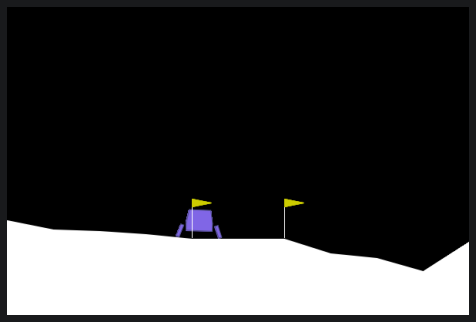

In [279]:
frames = []

def render_episode(tree, seed, episode_duration=1000):
    frames = []
    obs = env.reset(seed=seed)[0]

    for _ in range(episode_duration):
        frames.append(env.render())

        x = torch.from_numpy(obs.reshape((1, -1))).float()
        action = torch.argmax(tree.get_output_pt(x)).item()

        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            frames.append(env.render())
            break

    return frames

# gist to save gif from https://gist.github.com/botforge/64cbb71780e6208172bbf03cd9293553
def save_frames_as_gif(frames, path='./', filename='evolved_lander.gif'):
  plt.figure(figsize=(frames[0].shape[1] / 72.0, frames[0].shape[0] / 72.0), dpi=72)
  patch = plt.imshow(frames[0])
  plt.axis('off')
  def animate(i):
      patch.set_data(frames[i])
  anim = animation.FuncAnimation(plt.gcf(), animate, frames = len(frames), interval=50)
  anim.save(path + filename, writer='imagemagick', fps=60)

frames = render_episode(best, best_seed)
env.close()
save_frames_as_gif(frames)

## Play animation

<img src="evolved_lander.gif" width="750">

## Optimisation
The coefficients in the multi-tree aren't optimised. Here Q-learning (taken from https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html) is used to optimise the weights further. Incorporate coefficient optimisation in training your agent(s). Coefficient Optimisation can be expensive. Think about how often you want to optimise, when, which individuals etc.

In [276]:
batch_size = 128
GAMMA = 0.99

constants = best.get_subtrees_consts()

if len(constants)>0:
  optimizer = optim.AdamW(constants, lr=1e-3, amsgrad=True)

for _ in range(500):

  if len(constants)>0 and len(evo.memory)>batch_size:
    target_tree = copy.deepcopy(best)

    transitions = evo.memory.sample(batch_size)
    batch = Transition(*zip(*transitions))
    
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                        batch.next_state)), dtype=torch.bool)

    non_final_next_states = torch.cat([s for s in batch.next_state
                                               if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = best.get_output_pt(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(batch_size, dtype=torch.float)
    with torch.no_grad():
      next_state_values[non_final_mask] = target_tree.get_output_pt(non_final_next_states).max(1)[0].float()

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
   
    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(constants, 100)
    optimizer.step()

print(best.get_readable_repr())

scores = get_test_score(best)
print(scores)

best_idx = int(np.argmax(scores["episode_returns"]))
best_seed = VALIDATION_SEEDS[best_idx]

['(max((x_6-x_1),x_4)+(x_6-x_1))', 'max(x_2,max(x_2,max((log(abs(x_0))+abs((tanh(((abs(x_3)+abs((-3.117196559906006+3.115877987131463)))+x_4))+abs(tanh((sqrt(abs(abs(x_5)))-sqrt(abs(x_4)))))))),(max(x_4,x_0)+log(abs(x_4))))))', 'tanh(log(abs((log(abs(tanh(log(abs(x_3)))))/(x_1+sqrt(abs(x_6)))))))', 'max(((x_5*3.6567178280252466)+x_0),tanh((max(x_6,(((x_0*x_1)+(x_1/x_5))/(sqrt(abs(x_4))+log(abs(x_0)))))*-3.6411024529126887)))']
{'mean_return': 167.8213866397401, 'std_return': 178.36191761779548, 'min_return': -315.4184446094089, 'max_return': 282.9936886545947, 'episode_returns': [279.6484334636805, 15.048877202440863, 12.59751671847593, 257.6622972105346, 261.8980102147335, 249.0066112961903, 271.1514698663541, 221.67817367867963, 253.72844097853857, 282.9936886545947, 256.9426504451785, -283.806003893279, 276.134670435427, 26.035150536714994, 255.36041224613075, 247.7225395087827, 254.85683896950826, -315.4184446094089, 276.2157745626967, 256.9706253088283], 'episode_lengths': [188, 1

MovieWriter imagemagick unavailable; using Pillow instead.


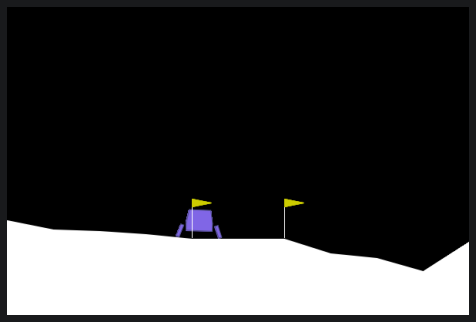

In [280]:
frames = []
frames = render_episode(best, best_seed)
env.close()
save_frames_as_gif(frames, filename='evolved_lander_RL.gif')

<img src="evolved_lander_RL.gif" width="750">